In [5]:
import numpy as np
import tomopy
import time
import matplotlib.pyplot as plt
from tomoDataClass import tomoData, simulate_projections

In [6]:
# Create a simple tomoData from shepp-logan phantom
print("Creating shepp-logan 3D phantom...")
phantom = tomopy.shepp3d(size=256)  # 128x128x128 volume

# Create angles (0 to π, 90 projections like a typical setup)
nang = 256
angles = tomopy.angles(nang=nang, ang1=0, ang2=180)

print(f"Phantom shape: {phantom.shape}")
print(f"Number of angles: {len(angles)}")

# Test 1: TomoPy forward projection (use_astra=False)
print("\n" + "="*60)
print("Testing TomoPy forward projection (use_astra=False)")
print("="*60)
start = time.time()
proj_tomopy = simulate_projections(phantom, angles, use_astra=False)
tomopy_time = time.time() - start
print(f"TomoPy projection shape: {proj_tomopy.shape}")
print(f"Time elapsed: {tomopy_time:.3f} seconds")

# Test 2: ASTRA forward projection (use_astra=True)
print("\n" + "="*60)
print("Testing ASTRA forward projection (use_astra=True)")
print("="*60)
start = time.time()
proj_astra = simulate_projections(phantom, angles, use_astra=True)
astra_time = time.time() - start
print(f"ASTRA projection shape: {proj_astra.shape}")
print(f"Time elapsed: {astra_time:.3f} seconds")

Creating shepp-logan 3D phantom...
Phantom shape: (256, 256, 256)
Number of angles: 256

Testing TomoPy forward projection (use_astra=False)
TomoPy projection shape: (256, 256, 256)
Time elapsed: 22.645 seconds

Testing ASTRA forward projection (use_astra=True)
ASTRA projection shape: (256, 256, 256)
Time elapsed: 0.352 seconds


In [7]:
# Compare results
print("\n" + "="*60)
print("Comparison and Analysis")
print("="*60)
print(f"\nTiming:")
print(f"  TomoPy:  {tomopy_time:.3f} s")
print(f"  ASTRA:   {astra_time:.3f} s")
print(f"  Speedup: {tomopy_time/astra_time:.2f}x")

# Numerical comparison
diff = proj_astra - proj_tomopy
mae = np.mean(np.abs(diff))
rmse = np.sqrt(np.mean(diff**2))
max_diff = np.max(np.abs(diff))

print(f"\nNumerical difference (ASTRA - TomoPy):")
print(f"  Max Absolute Error: {max_diff:.6f}")
print(f"  Mean Absolute Error: {mae:.6f}")
print(f"  RMSE: {rmse:.6f}")


Comparison and Analysis

Timing:
  TomoPy:  22.645 s
  ASTRA:   0.352 s
  Speedup: 64.33x

Numerical difference (ASTRA - TomoPy):
  Max Absolute Error: 16.000954
  Mean Absolute Error: 0.464203
  RMSE: 1.527985


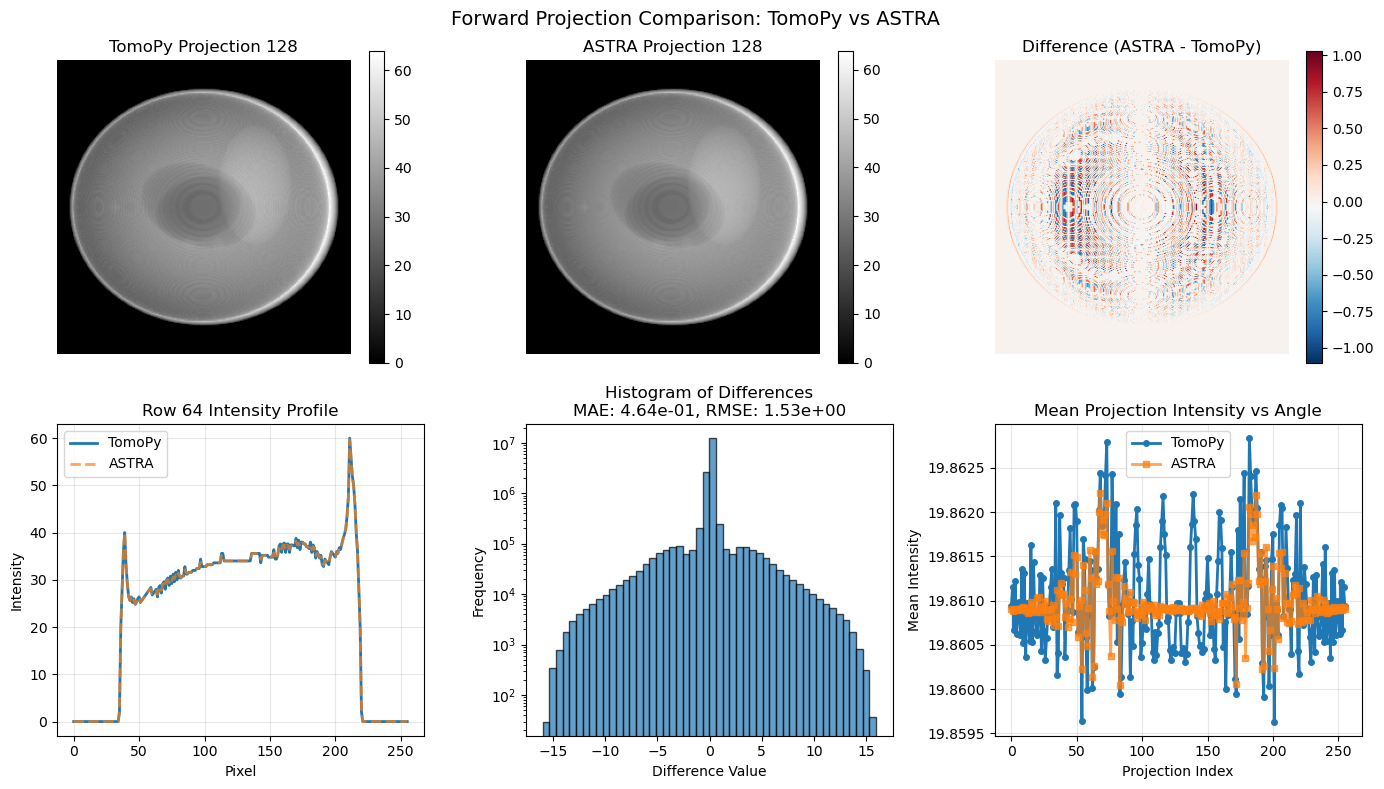


✓ Test complete!


In [8]:
# Visualization
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(f"Forward Projection Comparison: TomoPy vs ASTRA", fontsize=14)

# Middle projection (around angle 45°)
mid_proj_idx = nang // 2

# Row 1: TomoPy projection
im0 = axes[0, 0].imshow(proj_tomopy[mid_proj_idx], cmap='gray')
axes[0, 0].set_title(f'TomoPy Projection {mid_proj_idx}')
axes[0, 0].axis('off')
plt.colorbar(im0, ax=axes[0, 0])

# Row 1: ASTRA projection
im1 = axes[0, 1].imshow(proj_astra[mid_proj_idx], cmap='gray')
axes[0, 1].set_title(f'ASTRA Projection {mid_proj_idx}')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1])

# Row 1: Difference
im2 = axes[0, 2].imshow(diff[mid_proj_idx], cmap='RdBu_r')
axes[0, 2].set_title(f'Difference (ASTRA - TomoPy)')
axes[0, 2].axis('off')
plt.colorbar(im2, ax=axes[0, 2])

# Row 2: Intensity profile along middle row
row_idx = 64
axes[1, 0].plot(proj_tomopy[mid_proj_idx, row_idx, :], label='TomoPy', linewidth=2)
axes[1, 0].plot(proj_astra[mid_proj_idx, row_idx, :], label='ASTRA', linewidth=2, linestyle='--', alpha=0.7)
axes[1, 0].set_xlabel('Pixel')
axes[1, 0].set_ylabel('Intensity')
axes[1, 0].set_title(f'Row {row_idx} Intensity Profile')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Row 2: Histogram of differences
axes[1, 1].hist(diff.flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Difference Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Histogram of Differences\nMAE: {mae:.2e}, RMSE: {rmse:.2e}')
axes[1, 1].set_yscale('log')

# Row 2: Mean projection intensity
axes[1, 2].plot(proj_tomopy.mean(axis=(1,2)), label='TomoPy', linewidth=2, marker='o', markersize=4)
axes[1, 2].plot(proj_astra.mean(axis=(1,2)), label='ASTRA', linewidth=2, marker='s', markersize=4, alpha=0.7)
axes[1, 2].set_xlabel('Projection Index')
axes[1, 2].set_ylabel('Mean Intensity')
axes[1, 2].set_title('Mean Projection Intensity vs Angle')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Test complete!")